Ques-1 Apply PCA to reconstruct the Image from the Face94 Dataset.

Note : for this whole code to run faces94 dataset should be in the same directory as that of .ipynb is.

preparing data set

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
def load_images_from_folder(folder, n_persons=2, images_per_person=2, size=(100, 100)):
    """
    Loads `images_per_person` images each from first `n_persons` folders inside the given folder.
    All images are converted to grayscale, resized to 100*100, and flattened.
    Returns:
        - data_matrix: N x D matrix (N images, D pixels)
        - image_shape: (height, width)
        - image_files: list of file paths (for reference)
        - labels: labels (person names for clarity)
    """
    persons = sorted([d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))])
    data = []
    files = []
    labels = []
    for i, p in enumerate(persons[:n_persons]):
        person_folder = os.path.join(folder, p)
        imgs = sorted([f for f in os.listdir(person_folder) if f.endswith('.jpg')])
        for img in imgs[:images_per_person]:
            img_path = os.path.join(person_folder, img)
            img_arr = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img_arr = cv2.resize(img_arr, size)
            data.append(img_arr.flatten())
            files.append(img_path)
            labels.append(p)
    data = np.array(data)
    return data, size, files, labels


data prep for two person

In [ ]:
import cv2
import numpy as np

dataset = 'faces94'  # faces94 folder next to .ipynb (kept the faces94 in the same directory for this assignment)

# List person folders in each category
import os  # Needed to list folders and files!
female_persons = sorted([d for d in os.listdir(f"{dataset}/female") 
                         if os.path.isdir(f"{dataset}/female/{d}")])
male_persons = sorted([d for d in os.listdir(f"{dataset}/male") 
                         if os.path.isdir(f"{dataset}/male/{d}")])

# Pick first person from each
female1_folder = f"{dataset}/female/{female_persons[0]}"
male1_folder = f"{dataset}/male/{male_persons[0]}"

# Pick one image (jpg) from each person's folder
female1_imgs = sorted([f for f in os.listdir(female1_folder) if f.lower().endswith('.jpg')])
male1_imgs   = sorted([f for f in os.listdir(male1_folder) if f.lower().endswith('.jpg')])

female_img_path = f"{female1_folder}/{female1_imgs[0]}"
male_img_path   = f"{male1_folder}/{male1_imgs[0]}"

# Read and preprocess images
def read_preprocess(img_path, size=(100,100)):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, size)
    return img.flatten()

female_img_vec = read_preprocess(female_img_path)
male_img_vec = read_preprocess(male_img_path)

X = np.vstack([female_img_vec, male_img_vec])
labels = [female_persons[0], male_persons[0]]
files = [female_img_path, male_img_path]

print(f"Shape of X: {X.shape}")
print("Labels:", labels)
print("Files:", files)


Shape of X: (2, 10000)
Labels: ['9336923', '9326871']
Files: ['faces94/female/9336923/9336923.1.jpg', 'faces94/male/9326871/9326871.1.jpg']


Load 2 females and 2 males (one image each):

In [8]:
# Select first 2 folders from female and male persons
female_folders = female_persons[:2]
male_folders = male_persons[:2]

def load_one_image_from_folders(root, folders, size=(100, 100)):
    data = []
    files = []
    labels = []
    for f in folders:
        folder_path = f"{root}/{f}"
        imgs = sorted([img for img in os.listdir(folder_path) if img.lower().endswith('.jpg')])
        img_path = f"{folder_path}/{imgs[0]}"
        img_vec = read_preprocess(img_path, size)
        data.append(img_vec)
        files.append(img_path)
        labels.append(f)
    return np.array(data), files, labels

female_data, female_files, female_labels = load_one_image_from_folders(f"{dataset}/female", female_folders)
male_data, male_files, male_labels = load_one_image_from_folders(f"{dataset}/male", male_folders)

X = np.vstack([female_data, male_data])
labels = female_labels + male_labels
files = female_files + male_files

print(f"Shape of X: {X.shape}")  # Should output (4, 10000) for 4 images of 100x100
print("Labels:", labels)
print("Files:", files)


Shape of X: (4, 10000)
Labels: ['9336923', '9338535', '9326871', '9332898']
Files: ['faces94/female/9336923/9336923.1.jpg', 'faces94/female/9338535/9338535.1.jpg', 'faces94/male/9326871/9326871.1.jpg', 'faces94/male/9332898/9332898.1.jpg']


PCA from Scratch (Covariance + Eigen-Decomposition)

In [ ]:
# Center the data
mean_face = np.mean(X, axis=0)
X_centered = X - mean_face

# Compute covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)  # shape (D, D)

# Eigen-decomposition (use eigh, as the matrix is symmetric)
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort eigenvectors by eigenvalues (descending order)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Project data onto the principal components (PC scores)
pc_scores = np.dot(X_centered, eigenvectors)


reconstruction

In [10]:
def reconstruct_face(pc_scores, eigenvectors, mean_face, pc_range):
    rec = mean_face + np.dot(pc_scores[:, pc_range], eigenvectors[:, pc_range].T)
    return rec


Pick first two images for demo:

In [18]:
# Reconstruct using PC1 alone
rec_img1_pc1 = reconstruct_face(pc_scores[0:1], eigenvectors, mean_face, slice(0, 1)).reshape((100, 100))

# Reconstruct using PC2 alone
rec_img1_pc2 = reconstruct_face(pc_scores[0:1], eigenvectors, mean_face, slice(1, 2)).reshape((100, 100))

# Reconstruct using PC3 alone
rec_img1_pc3 = reconstruct_face(pc_scores[0:1], eigenvectors, mean_face, slice(2, 3)).reshape((100, 100))

# Reconstruct using all three PCs together (PC1-PC3)
rec_img1_pc1_3 = reconstruct_face(pc_scores[0:1], eigenvectors, mean_face, slice(0, 3)).reshape((100, 100))


rec_img1_pc5 = reconstruct_face(pc_scores[0:1], eigenvectors, mean_face, slice(4, 5)).reshape((100, 100))
rec_img1_pc6 = reconstruct_face(pc_scores[0:1], eigenvectors, mean_face, slice(5, 6)).reshape((100, 100))
rec_img1_pc7 = reconstruct_face(pc_scores[0:1], eigenvectors, mean_face, slice(6, 7)).reshape((100, 100))
rec_img1_pc8 = reconstruct_face(pc_scores[0:1], eigenvectors, mean_face, slice(7, 8)).reshape((100, 100))
rec_img1_pc9 = reconstruct_face(pc_scores[0:1], eigenvectors, mean_face, slice(8,9)).reshape((100, 100))
rec_img1_pc5_9 = reconstruct_face(pc_scores[0:1], eigenvectors, mean_face, slice(5,9)).reshape((100, 100))

rec_img2_pc1 = reconstruct_face(pc_scores[1:2], eigenvectors, mean_face, slice(0, 1)).reshape((100, 100))
rec_img2_pc2 = reconstruct_face(pc_scores[1:2], eigenvectors, mean_face, slice(1, 2)).reshape((100, 100))
rec_img2_pc3 = reconstruct_face(pc_scores[1:2], eigenvectors, mean_face, slice(2, 3)).reshape((100, 100))
rec_img2_pc5 = reconstruct_face(pc_scores[1:2], eigenvectors, mean_face, slice(4,5)).reshape((100, 100))
rec_img2_pc6 = reconstruct_face(pc_scores[1:2], eigenvectors, mean_face, slice(5, 6)).reshape((100, 100))
rec_img2_pc7 = reconstruct_face(pc_scores[1:2], eigenvectors, mean_face, slice(6, 7)).reshape((100, 100))
rec_img2_pc8 = reconstruct_face(pc_scores[1:2], eigenvectors, mean_face, slice(7, 8)).reshape((100, 100))
rec_img2_pc9 = reconstruct_face(pc_scores[1:2], eigenvectors, mean_face, slice(8, 9)).reshape((100, 100))
rec_img2_pc1_3 = reconstruct_face(pc_scores[1:2], eigenvectors, mean_face, slice(5,9)).reshape((100, 100))


rec_img2_pc5_9 = reconstruct_face(pc_scores[1:2], eigenvectors, mean_face, slice(4, 9)).reshape((100, 100))

# Reconstruct images 3 and 4 (index 2 and 3)
rec_img3_pc1_3 = reconstruct_face(pc_scores[2:3], eigenvectors, mean_face, slice(0, 3)).reshape((100, 100))
rec_img3_pc5_9 = reconstruct_face(pc_scores[2:3], eigenvectors, mean_face, slice(4, 9)).reshape((100, 100))

rec_img4_pc1_3 = reconstruct_face(pc_scores[3:4], eigenvectors, mean_face, slice(0, 3)).reshape((100, 100))
rec_img4_pc5_9 = reconstruct_face(pc_scores[3:4], eigenvectors, mean_face, slice(4, 9)).reshape((100, 100))




Plotting:

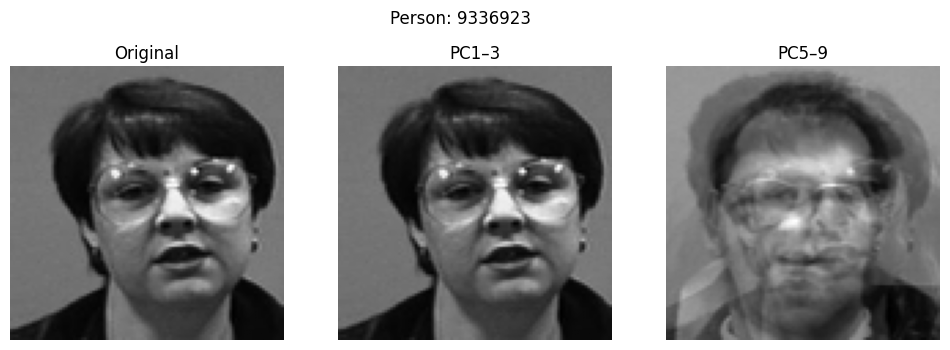

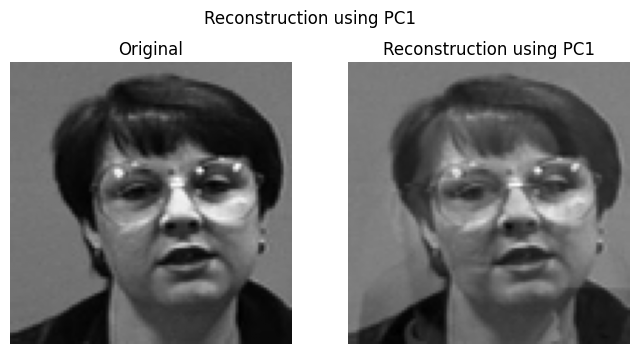

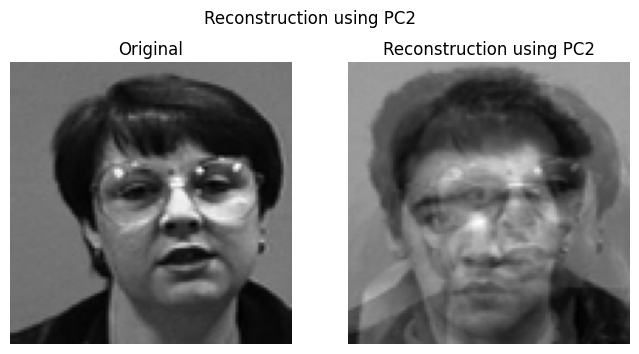

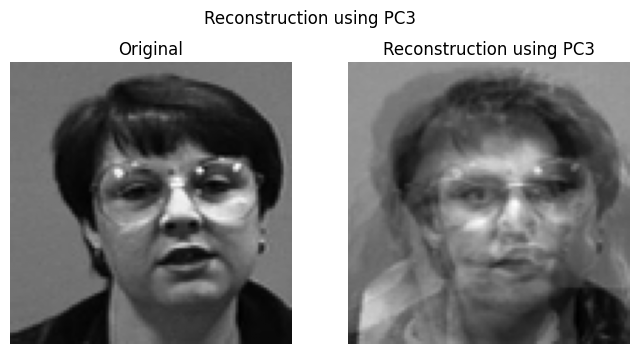

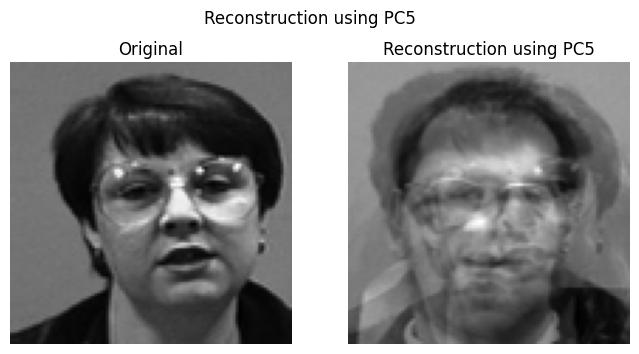

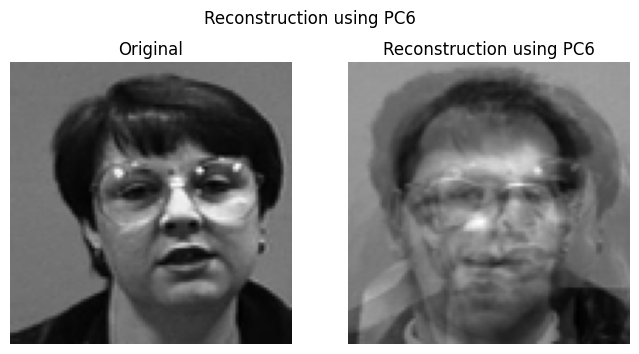

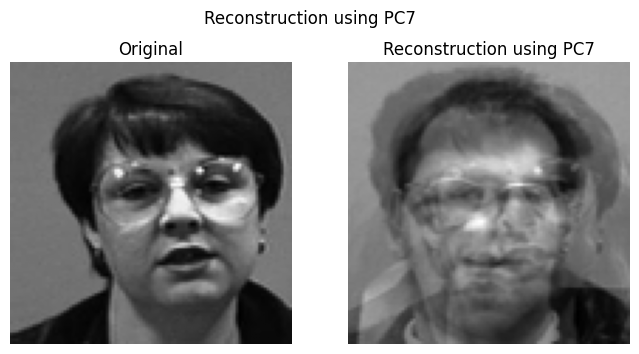

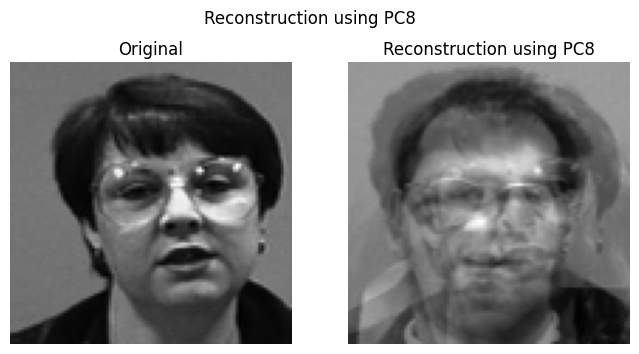

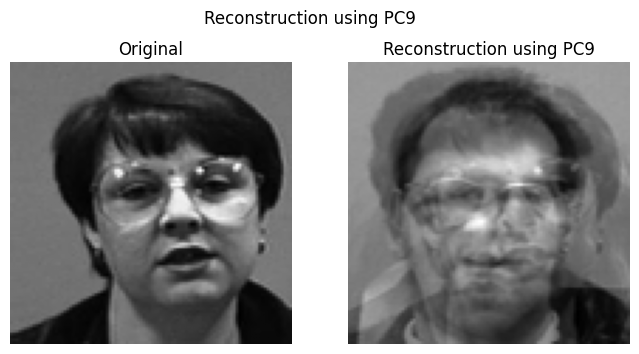

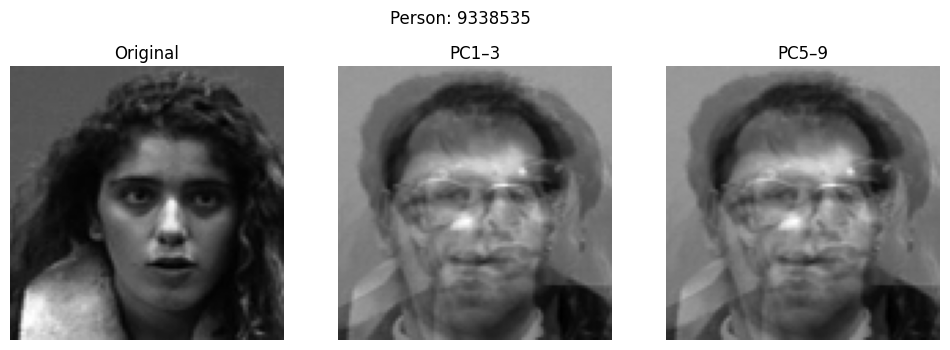

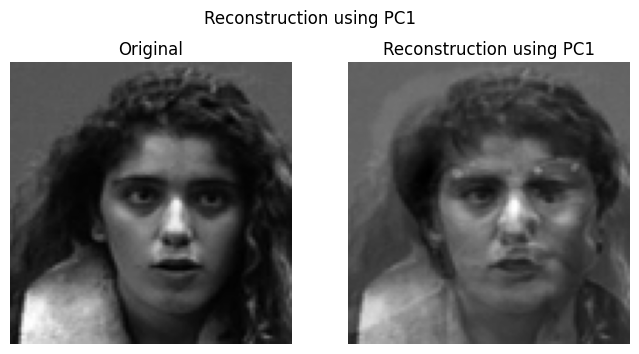

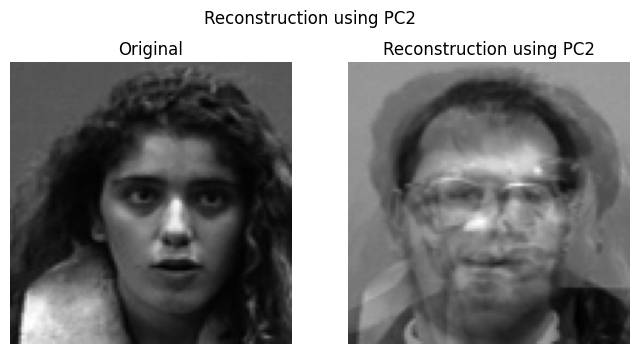

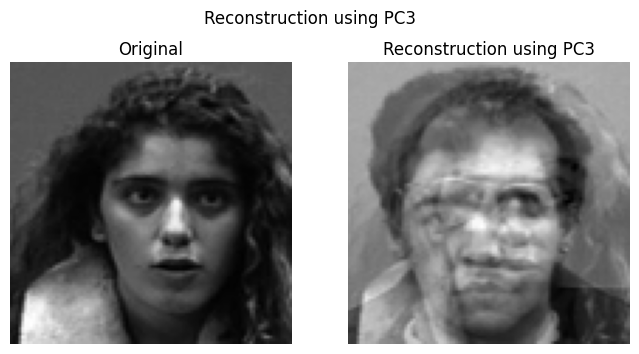

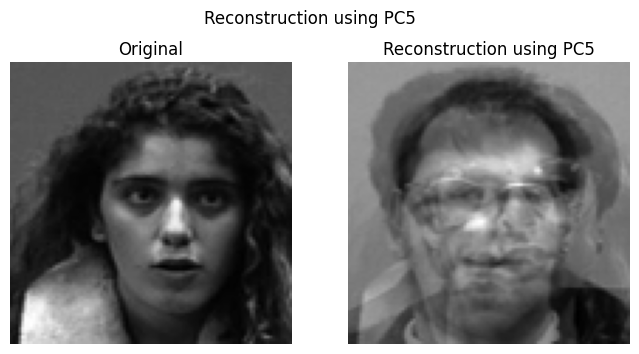

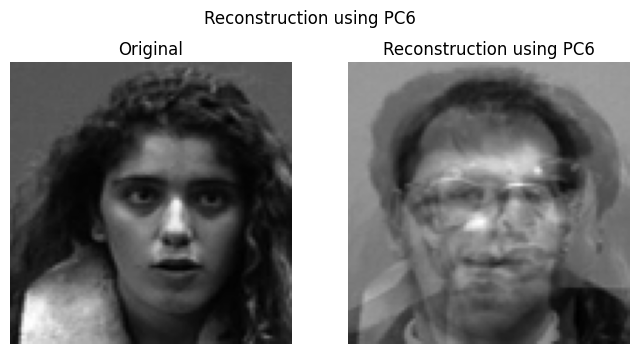

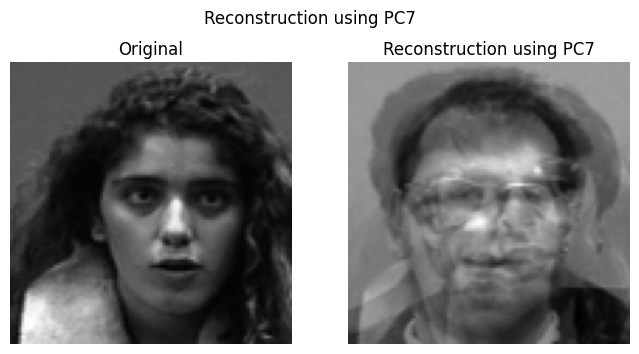

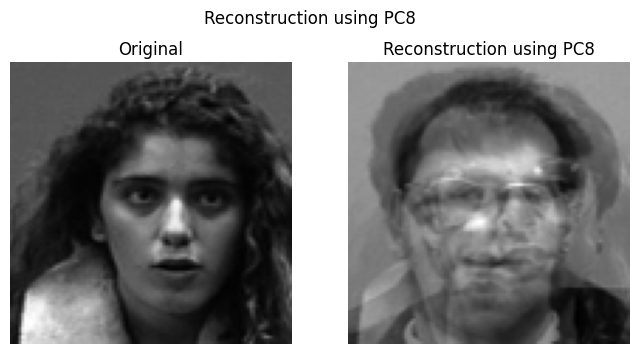

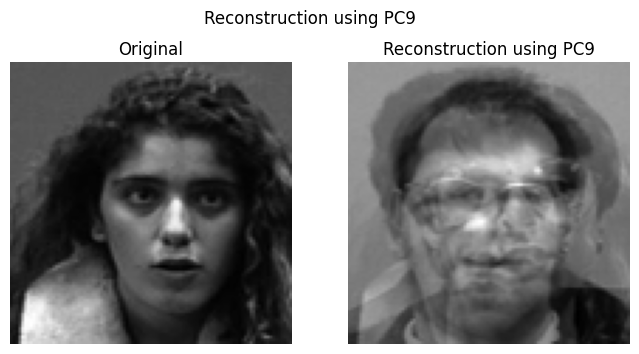

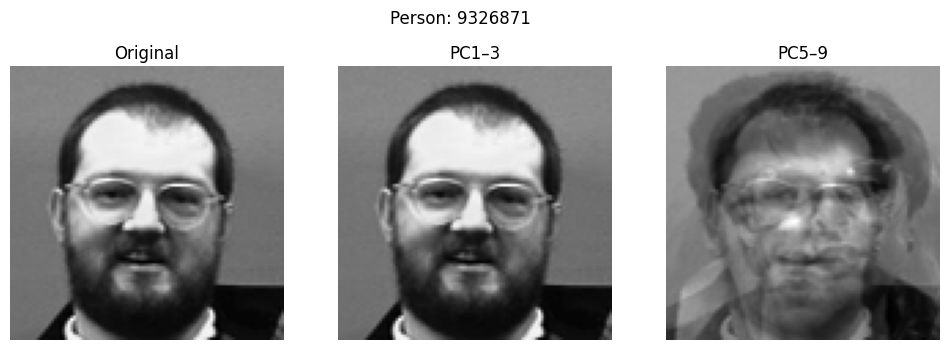

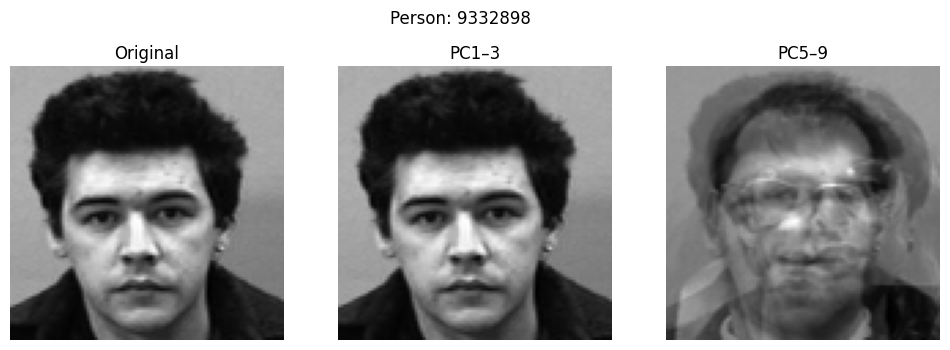

In [19]:
def plot_cmp(original, rec_1_3, rec_5_9, size, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.imshow(original.reshape(size), cmap='gray')
    plt.title('Original')
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.imshow(rec_1_3, cmap='gray')
    plt.title('PC1–3')
    plt.axis('off')
    plt.subplot(1,3,3)
    plt.imshow(rec_5_9, cmap='gray')
    plt.title('PC5–9')
    plt.axis('off')
    plt.suptitle(title)
    plt.show()
def plot_single_reconstruction(original, reconstructed, size, title_original='Original', title_reconstructed='Reconstruction'):
    plt.figure(figsize=(8, 4))
    
    plt.subplot(1, 2, 1)
    plt.imshow(original.reshape(size), cmap='gray')
    plt.title(title_original)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(title_reconstructed)
    plt.axis('off')
    
    plt.suptitle(title_reconstructed)
    plt.show()
plot_cmp(X[0], rec_img1_pc1_3, rec_img1_pc5_9, (100,100), f'Person: {labels[0]}')
plot_single_reconstruction(X[0], rec_img1_pc3, (100,100), title_reconstructed='Reconstruction using PC1')
plot_single_reconstruction(X[0], rec_img1_pc2, (100,100), title_reconstructed='Reconstruction using PC2')
plot_single_reconstruction(X[0], rec_img1_pc1, (100,100), title_reconstructed='Reconstruction using PC3')
plot_single_reconstruction(X[0], rec_img1_pc5, (100,100), title_reconstructed='Reconstruction using PC5')
plot_single_reconstruction(X[0], rec_img1_pc6, (100,100), title_reconstructed='Reconstruction using PC6')
plot_single_reconstruction(X[0], rec_img1_pc7, (100,100), title_reconstructed='Reconstruction using PC7')
plot_single_reconstruction(X[0], rec_img1_pc8, (100,100), title_reconstructed='Reconstruction using PC8')
plot_single_reconstruction(X[0], rec_img1_pc9, (100,100), title_reconstructed='Reconstruction using PC9')

plot_cmp(X[1], rec_img2_pc1_3, rec_img2_pc5_9, (100,100), f'Person: {labels[1]}')
plot_single_reconstruction(X[1], rec_img2_pc1, (100,100), title_reconstructed='Reconstruction using PC1')
plot_single_reconstruction(X[1], rec_img2_pc2, (100,100), title_reconstructed='Reconstruction using PC2')
plot_single_reconstruction(X[1], rec_img2_pc3, (100,100), title_reconstructed='Reconstruction using PC3')
plot_single_reconstruction(X[1], rec_img2_pc5, (100,100), title_reconstructed='Reconstruction using PC5')
plot_single_reconstruction(X[1], rec_img2_pc6, (100,100), title_reconstructed='Reconstruction using PC6')
plot_single_reconstruction(X[1], rec_img2_pc7, (100,100), title_reconstructed='Reconstruction using PC7')
plot_single_reconstruction(X[1], rec_img2_pc8, (100,100), title_reconstructed='Reconstruction using PC8')
plot_single_reconstruction(X[1], rec_img2_pc9, (100,100), title_reconstructed='Reconstruction using PC9')
plot_cmp(X[2], rec_img3_pc1_3, rec_img3_pc5_9, (100,100), f'Person: {labels[2]}')
plot_cmp(X[3], rec_img4_pc1_3, rec_img4_pc5_9, (100,100), f'Person: {labels[3]}')


QUESTION - 2 APPLYING LDA TO FACES94

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

dataset_root = 'faces94'

def read_preprocess(img_path, size=(100, 100)):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, size)
    return img.flatten()

def load_persons(root_subdir, person_indices, images_per_person=5, size=(100, 100)):
    """
    root_subdir (main subdirectory inside the faces94 dataset): 'female' or 'male' or 'malestaff'
    person_indices: list of indices into the sorted person-folder list
    """
    base = os.path.join(dataset_root, root_subdir)
    persons = sorted([d for d in os.listdir(base) if os.path.isdir(os.path.join(base, d))])
    X_list, y_list, label_list = [], [], []
    for idx in person_indices:
        person_name = persons[idx]
        folder = os.path.join(base, person_name)
        imgs = sorted([f for f in os.listdir(folder) if f.lower().endswith('.jpg')])
        for img_name in imgs[:images_per_person]:
            path = os.path.join(folder, img_name)
            X_list.append(read_preprocess(path, size))
            y_list.append(person_name)
        label_list.append(person_name)
    X = np.array(X_list)
    y = np.array(y_list)
    return X, y, label_list, size


In [29]:
# Example combination 1: 2 females (idx 0,1) + 1 male (idx 0)
X_f1, y_f1, names_f1, size = load_persons('female', [0,1,2,3,4,5,6], images_per_person=5)
X_m1, y_m1, names_m1, _    = load_persons('male',   [0,1,2,3],   images_per_person=5)

X = np.vstack([X_f1, X_m1])
labels = np.concatenate([y_f1, y_m1])

print(X.shape, labels.shape)  # (N, 10000), (N,)


(55, 10000) (55,)


In [30]:
labels = np.array(labels)
class_names, y_int = np.unique(labels, return_inverse=True)  # 0..C-1
C = len(class_names)
N, D = X.shape
print("Classes:", class_names, "C =", C)


Classes: ['9326871' '9332898' '9336923' '9338446' '9338454' '9338535' 'anpage'
 'asamma' 'asewil' 'astefa' 'drbost'] C = 11


In [ ]:
mu = np.mean(X, axis=0)                 # global mean
class_means = np.zeros((C, D))
class_counts = np.zeros(C, dtype=int)

for c in range(C):
    X_c = X[y_int == c]
    class_counts[c] = X_c.shape[0]
    class_means[c] = np.mean(X_c, axis=0)

S_W = np.zeros((D, D), dtype=np.float64)
S_B = np.zeros((D, D), dtype=np.float64)

# Within-class scatter -> Sw
for c in range(C):
    X_c = X[y_int == c]
    mean_c = class_means[c]
    Xc_centered = X_c - mean_c
    S_W += Xc_centered.T @ Xc_centered

# Between-class scatter -> Sb
for c in range(C):
    n_c = class_counts[c]
    mean_c = class_means[c].reshape(-1, 1)
    mu_col = mu.reshape(-1, 1)
    diff = mean_c - mu_col
    S_B += n_c * (diff @ diff.T)


In [32]:
eps = 1e-6
S_W_reg = S_W + eps * np.eye(D)     # regularization

# Generalized eigenproblem
eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(S_W_reg) @ S_B)

idx = np.argsort(eigvals.real)[::-1]
eigvals = eigvals.real[idx]
eigvecs = eigvecs[:, idx].real

max_dims = min(C - 1, 2)           # 2D for visualization if C>=3
W_lda = eigvecs[:, :max_dims]      # D x k
print("W_lda shape:", W_lda.shape)


W_lda shape: (10000, 2)


In [33]:
X_centered = X - mu
X_lda = X_centered @ W_lda         # N x k

print("X_lda shape:", X_lda.shape)


X_lda shape: (55, 2)


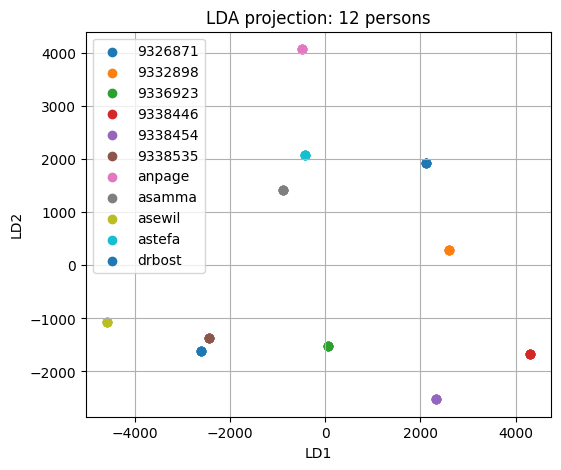

In [35]:
def plot_lda_scatter(X_lda, y_int, class_names, title):
    plt.figure(figsize=(6, 5))
    if X_lda.shape[1] == 1:
        # 1D: plot along x-axis
        for c, name in enumerate(class_names):
            pts = X_lda[y_int == c, 0]
            plt.scatter(pts, np.zeros_like(pts), label=name)
        plt.xlabel('LD1')
        plt.yticks([])
    else:
        for c, name in enumerate(class_names):
            pts = X_lda[y_int == c]
            plt.scatter(pts[:, 0], pts[:, 1], label=name)
        plt.xlabel('LD1')
        plt.ylabel('LD2')
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_lda_scatter(X_lda, y_int, class_names, "LDA projection: 12 persons")


Q3. Singular Value Decomposition (SVD) for Image Denoising

 Pick one face and reshape to 2D

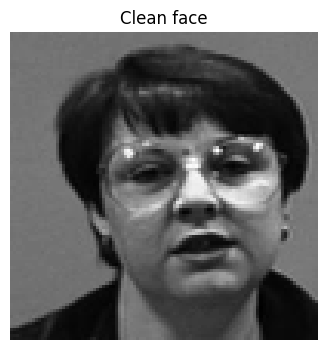

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Take first face from X (shape: N x 10000)
img_clean = X[0].reshape(100, 100).astype(np.float64)

plt.figure(figsize=(4,4))
plt.imshow(img_clean, cmap='gray')
plt.title('Clean face')
plt.axis('off')
plt.show()


 Add noise (Gaussian or salt‑and‑pepper)

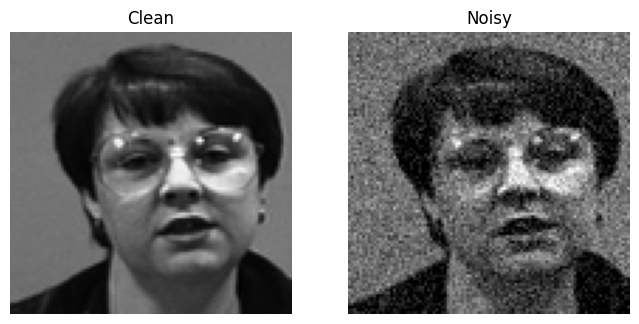

In [ ]:
import numpy as np

def add_gaussian_noise(img, mean=0, std=20):
    noise = np.random.normal(mean, std, img.shape)
    noisy = img + noise
    noisy = np.clip(noisy, 0, 255)
    return noisy

def add_salt_pepper_noise(img, amount=0.02, s_vs_p=0.5):
    noisy = img.copy()
    num_pixels = img.size
    num_salt = int(amount * num_pixels * s_vs_p)
    num_pepper = int(amount * num_pixels * (1 - s_vs_p))

    # Salt noise
    coords = (np.random.randint(0, img.shape[0], num_salt),
              np.random.randint(0, img.shape[1], num_salt))
    noisy[coords] = 255

    # Pepper noise
    coords = (np.random.randint(0, img.shape[0], num_pepper),
              np.random.randint(0, img.shape[1], num_pepper))
    noisy[coords] = 0

    return noisy

# Choose one type of noise:
img_noisy = add_gaussian_noise(img_clean, mean=0, std=20)
# or:
# img_noisy = add_salt_pepper_noise(img_clean, amount=0.02)  [this is for adding salt and pepper noise as per the requirement]

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(img_clean, cmap='gray'); plt.title('Clean'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(img_noisy, cmap='gray'); plt.title('Noisy'); plt.axis('off')
plt.show()


Manual “SVD” using eigen‑decomposition of A`A

In [ ]:
# Treating the noisy image as matrix A (m x n)
A = img_noisy.astype(np.float64)
m, n = A.shape  # should be 100 x 100

# Step 1: computing A^T A (n x n)
ATA = A.T @ A

# Step 2: eigen‑decomposition of A^T A (symmetric)
eigvals, V = np.linalg.eigh(ATA)   # V: n x n, columns are eigenvectors

# Step 3: sort eigenvalues/vectors in descending order
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
V = V[:, idx]

# Step 4: singular values = sqrt of eigenvalues (clip small negatives for numerical errors)
sing_vals = np.sqrt(np.clip(eigvals, 0, None))  # shape (n,)

# Step 5: construct U = A V Σ^{-1}
tol = 1e-10
Sigma_inv = np.zeros_like(sing_vals)
Sigma_inv[sing_vals > tol] = 1.0 / sing_vals[sing_vals > tol]

# Scale columns of V by 1/sigma_i to get U
U = A @ (V * Sigma_inv)   # broadcasting (converting to matrix): each column j of V scaled by Sigma_inv[j]

print("U shape:", U.shape)        # (100, 100)
print("sing_vals shape:", sing_vals.shape)
print("V shape:", V.shape)        # (100, 100)


U shape: (100, 100)
sing_vals shape: (100,)
V shape: (100, 100)


Low‑rank reconstruction using top k singular values

In [ ]:
def svd_like_reconstruct(U, sing_vals, V, k):
    """
    Reconstruct A_k = sum_{i=1}^k sigma_i u_i v_i^T
    U: m x n, sing_vals: length n, V: n x n
    """
    Uk = U[:, :k]                    # m x k
    Sk = np.diag(sing_vals[:k])      # k x k
    Vk = V[:, :k].T                  # k x n  (rows are v_i^T)
    A_k = Uk @ Sk @ Vk               # m x n
    A_k = np.clip(A_k, 0, 255)
    return A_k

ks = [5, 20, 50]
reconstructions = {}
for k in ks:
    reconstructions[k] = svd_like_reconstruct(U, sing_vals, V, k)

Plot clean, noisy, and SVD‑denoised images for different k

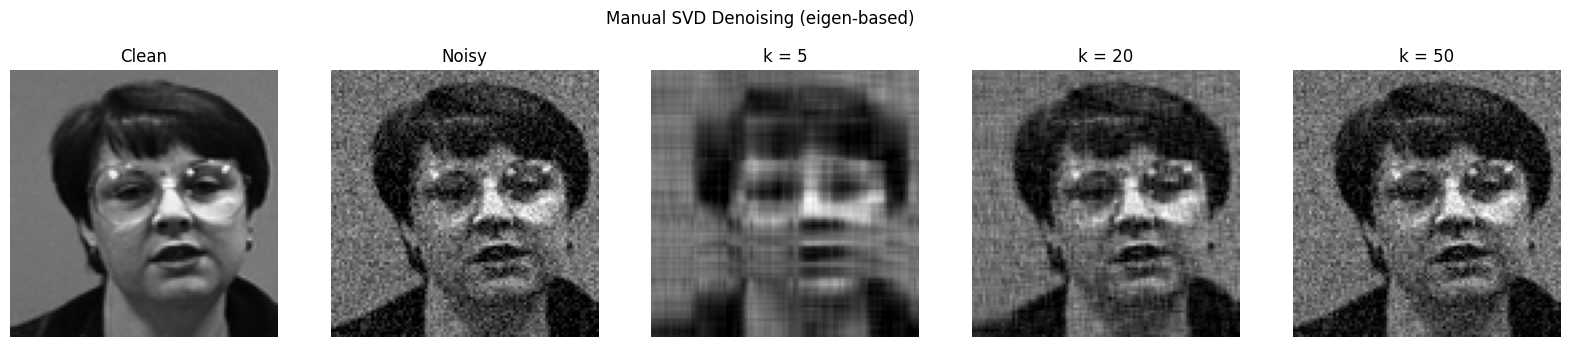

In [ ]:
def plot_svd_denoising(img_clean, img_noisy, reconstructions, ks):
    n = len(ks) + 2
    plt.figure(figsize=(4*n, 4))

    plt.subplot(1, n, 1)
    plt.imshow(img_clean, cmap='gray')
    plt.title('Clean')
    plt.axis('off')

    plt.subplot(1, n, 2)
    plt.imshow(img_noisy, cmap='gray')
    plt.title('Noisy')
    plt.axis('off')

    for i, k in enumerate(ks, start=3):
        plt.subplot(1, n, i)
        plt.imshow(reconstructions[k], cmap='gray')
        plt.title(f'k = {k}')
        plt.axis('off')

    plt.suptitle('Manual SVD Denoising (eigen-based)')
    plt.show()

plot_svd_denoising(img_clean, img_noisy, reconstructions, ks)